# Prism Dispersion Model 

In [77]:
####Import the required libraries

import numpy as np
import matplotlib.pyplot as plt

In [78]:
####Define the prism refractive index as a function of wavelength

def refractive_index(wavelength):
    return 1.5 + (0.004/wavelength**2)

####Define visible light wavelengths
wavelengths = {
    'Violet': 0.40,
    'Blue': 0.45,
    'Cyan': 0.5,
    'Green': 0.55,
    'Yellow': 0.58,
    'Orange': 0.62,
    'Red': 0.7
}

#Example to compute and compare the refractive index for two different wavelengths to check the function
print(refractive_index(wavelengths['Violet']))   # violet
print(refractive_index(wavelengths['Red']))   # red



1.525
1.5081632653061225


Next, I'm going to define the parameters of my prism. Since we are working with an equilateral triangle, the length of all sides is the same (here I assumed 10) and the internal angles are all 60 degrees. As a result, I can calculate the height of the triangle using Cos(60) and thus, define each corner's coordinates for my dispersion figure.

In [79]:
#### Define the parameters of the prism

L = 10
h = np.sqrt(3) * L / 2

####Corners of the prism
A = np.array([0,0])
B = np.array([L,0])
C = np.array([L/2,h])

####Sides of prism
sides = [
    (A, C),  
    (C, B),   
    (B, A)   
]

####Prism center
prism_center = (A + B + C) / 3

Before building the main core of the model, I'm going to define some functions that would help with the operations on incident ray to the prism and the normal vector to the prism surface.

In [80]:
####Function to normalize a vector. This is useful to calculate the unit normal vectors to the sides of the prism
def normalize(v):
    return v / np.linalg.norm(v)

####Function to see if two vectors are parallel. This is useful to notice if the incident ray of light is parallel to the prism side by calculating the cross product
def cross2d(a,b):
    return a[0] * b[1] - a[1] * b[0]

####Function to calculate the normal vector to the prism side
def normal_vector(v):
    return np.array([-v[1], v[0]])

####Function to calculate a vector's angle with respect to x-axis
def direction_angle_deg(v):
    return np.degrees(np.arctan2(v[1], v[0]))

#### Function to keep all the angles with respect to x-axis between 180 and -180 degrees. This is useful to keep the angles in a consistent range for comparison
def wrap_angle_deg(angle):
    return (angle + 180) % 360 - 180

####Calculate the outward and inward normal vectors for each side of the prism
def outward_normal(side_start, side_end, prism_ceter):
    side_vec = side_end - side_start
    n = normal_vector(side_vec)
    n = normalize(n)
    midpoint = (side_start + side_end) / 2
    # check to see if it is inward and flip it
    if np.dot(n, midpoint - prism_center) < 0:
        n = -n
    return n

def inward_normal(side_start, side_end, prism_ceter):
    return -outward_normal(side_start, side_end, prism_ceter)

def normal_angle_to_horizon_deg(side_start, side_end, prism_center, inward=True):
    if inward:
        n = inward_normal(side_start, side_end, prism_center)
    else:
        n = outward_normal(side_start, side_end, prism_center)
    return direction_angle_deg(n)

#test the function
x = normal_angle_to_horizon_deg(C, B, prism_center, inward=False)
print(x)

y = inward_normal(C, B, prism_center)
print(y)

30.000000000000004
[-0.8660254 -0.5      ]


Next, I'll define my ray as r(t) = O + tD, where O is the origin of the ray, t is how far along the ray we traveled, and D is the normalized vector representing the direction of the ray. After that, I define the left side of the prism as the face through which the light ray will enter the prism using s(u) = A + u(C - A), where A and C are the start and end point of the prism's left side, and u is a parameter between 0 to 1 that helps us cover all the points between points A and C. Using the ray and the prism left face equation, I will calculate the intersection point of the ray and the left face. In addition, using snell's law, I'll calculate the refraction angle of the ray entering and exiting the prism.

In [81]:
from math import degrees
####Function to calculate the direction of the incident ray based on the incident angle
def make_incident_ray(ray_origin, incident_angle, entry_side_start, entry_side_end, prism_center):
    normal_degree = normal_angle_to_horizon_deg(entry_side_start, entry_side_end, prism_center, inward=False) #outward normal degree to horizon
    eta = normal_degree + incident_angle - 180            # angle of the ray with respect to the horizontal axis
    ray_dir = np.array([np.cos(np.radians(eta)), np.sin(np.radians(eta))])  # direction vector of the ray
    return ray_origin, ray_dir, eta

####Function to calculate the intersection of the ray with the prism left side

def ray_prism_intersection(ray_origin, ray_dir, side_start, side_end):
    O_x, O_y = ray_origin
    D_x, D_y = ray_dir
    A_x, A_y= side_start
    S_x, S_y = side_end - side_start
    
    denom = cross2d(ray_dir, side_end - side_start)
    if np.isclose(denom, 0):
        return None  # No intersection, ray is parallel to the side
    # at intersection, we have O + tD = A + uS, so we need to solve for t and u
    # solve for t
    t = ((A_x - O_x) * S_y - (A_y - O_y) * S_x) / (D_x * S_y - D_y * S_x)
    # solve for u
    u = ((A_x - O_x) * D_y - (A_y - O_y) * D_x) / (D_x * S_y - D_y * S_x)
    
    #check if the intersection is physically valid
    if t >= 0 and 0 <= u <= 1:
        intersection_point = np.array([O_x + t * D_x, O_y + t * D_y])
        return intersection_point, t, u
    return None  # No valid intersection

#### Calculate the entering angle of refraction using Snell's law
def snell_law_enter(incident_angle, wavelength, n_air):
    n_prism = round(refractive_index(wavelength), 3)
    theta_1 = np.radians(incident_angle)
    theta_2 = np.arcsin(round((n_air * np.sin(theta_1)) / n_prism, 4))
    return round(np.degrees(theta_2), 4), n_prism

#### Function to calculate the direction of the ray inside the prism after refraction
def make_inside_ray(entry_point, refracted_angle, entry_side_start, entry_side_end, prism_center):
    normal_degree = normal_angle_to_horizon_deg(entry_side_start, entry_side_end, prism_center, inward=True) #inward normal degree to horizon
    eta = refracted_angle + normal_degree           # angle of the ray with respect to the horizontal axis
    inside_dir = np.array([np.cos(np.radians(eta)), np.sin(np.radians(eta))])
    return entry_point, inside_dir, eta

#### Function to calculate the intersection of the ray inside the prism with the other sides of the prism
def same_side(side1, side2):
    return np.allclose(side1[0], side2[0]) and np.allclose(side1[1], side2[1])
    
def ray_prism_exit_intersection(ray_origin, ray_dir, exclude_side):
    exit = []
    inside_origin = ray_origin + 1e-6 * ray_dir  # move the origin slightly inside the prism to avoid numerical issues
    for side in sides:
        if same_side(side, exclude_side):
            continue # skip the side we entered from
        results = ray_prism_intersection(inside_origin, ray_dir, side[0], side[1])
        if results is not None:
            intersection_point, t, u = results
            exit.append((intersection_point, t, u, side))

    if len(exit) == 0:
        return None

    exit.sort(key=lambda item: item[1]) #sort the hit by t
    return exit[0]

#### Function to calculate the exiting angle of refraction using Snell's law
def snell_law_exit(eta, exit_side_start, exit_side_end, wavelength, n_air):
    n_prism = round(refractive_index(wavelength), 3)
    normal_degree = normal_angle_to_horizon_deg(exit_side_start, exit_side_end, prism_center, inward=False) #inward normal degree to horizon
    if same_side((exit_side_start, exit_side_end), (C, B)):
        theta_1 = abs(wrap_angle_deg(eta - normal_degree)) #the incident angle inside the prism based on the horizon angle of the inside ray and the inward normal of exit face
    else:
        theta_1 = abs(wrap_angle_deg(eta - normal_degree)) #the incident angle inside the prism based on the horizon angle of the inside ray and the inward normal of exit face
    value = n_prism * np.sin(np.radians(theta_1)) / n_air
    if abs(value) > 1:
        print("Total internal reflection occurs, no refraction outside the prism")
        return None, theta_1   # total internal reflection
    theta_2 = np.arcsin(round((n_prism * np.sin(np.radians(theta_1))) / n_air, 4))
    return round(np.degrees(theta_2), 4), theta_1

#### Function to calculate the direction of the dispersion outside of the prism after refraction
def make_exit_ray(exit_point, refracted_angle, side, exit_side_start, exit_side_end):
    if same_side((exit_side_start, exit_side_end), (C, B)):
        normal_degree = normal_angle_to_horizon_deg(exit_side_start, exit_side_end, prism_center, inward=False) #outward normal degree to horizon
        eta = normal_degree  - refracted_angle            # angle of the ray with respect to the horizontal axis
        exit_dir = np.array([np.cos(np.radians(eta)), np.sin(np.radians(eta))])
    else:
        normal_degree = normal_angle_to_horizon_deg(exit_side_start, exit_side_end, prism_center, inward=False) #outward normal degree to horizon
        eta = normal_degree + refracted_angle           # angle of the ray with respect to the horizontal axis
        exit_dir = np.array([np.cos(np.radians(eta)), np.sin(np.radians(eta))])

    return exit_point, exit_dir, eta

Model implementation (one wavelength)

Origin: [0.5 2. ]
Direction: [-0.08715574 -0.9961947 ]
Angle: -95.0
Ray entered the prism at: [0.38307131 0.66349897]
Refracted angle inside the prism: -36.7983
Ray inside the prism starts at: [0.38307171 0.66349806] with direction: [ 0.39396918 -0.91912365]
Angle inside the prism: -66.7983
Ray exits the prism at: [0.66747064 0.        ] through side: (array([10,  0]), array([0, 0]))
Refracted angle outside the prism: 36.5911
Incident angle inside the prism: 23.201700000000017
Ray exits the prism at: [0.66747064 0.        ] with direction: [ 0.59610016 -0.80291008]
Exit angle: -53.4089


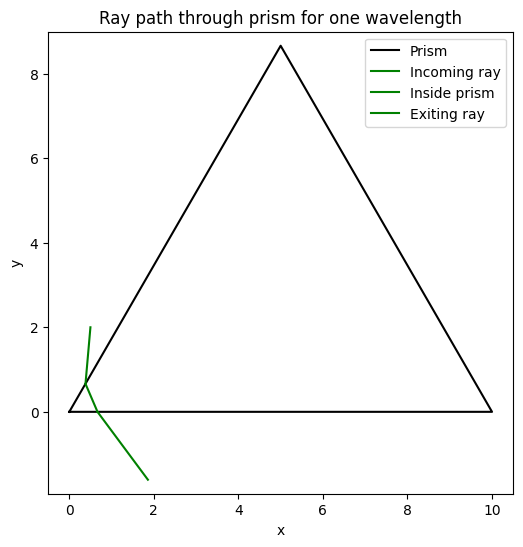

In [82]:
n_air = 1
ray_origin = np.array([0.5, 2])  # Starting point of the ray
incident_angle = -65 # Incident angle in degrees

####Origin and direction of the incoming ray
incoming_origin, incoming_dir, incoming_angle = make_incident_ray(ray_origin, incident_angle, A, C, prism_center)
print("Origin:", incoming_origin)
print("Direction:", incoming_dir)
print("Angle:", incoming_angle)

####Calculate the intersection of the incoming ray with the left side of the prism
entry_result = ray_prism_intersection(incoming_origin, incoming_dir, A, C)

if entry_result is None:
    print("Ray missed the prism")
else:
    entry_point, t_enter, u_enter = entry_result
    print("Ray entered the prism at:", entry_point)

####Calculate the refracted angle inside the prism using Snell's law    
wavelength = 0.55   # green
refracted_enter_angle, n_prism = snell_law_enter(incident_angle, wavelength, n_air)
print("Refracted angle inside the prism:", refracted_enter_angle)

####Calculate the direction of the ray inside the prism after refraction
inside_origin, inside_dir, inside_angle = make_inside_ray(entry_point, refracted_enter_angle, A, C, prism_center)
inside_origin = inside_origin + 1e-6 * inside_dir  # move the origin slightly inside the prism to avoid numerical issues
print("Ray inside the prism starts at:", inside_origin, "with direction:", inside_dir)
print("Angle inside the prism:", inside_angle)

#### Calculate the intersection of the ray inside the prism with the other sides of the prism
exit_result = ray_prism_exit_intersection(inside_origin, inside_dir, exclude_side=(A, C))

if exit_result is None:
    print("No exit found")
else:
    exit_point, t_exit, u_exit, exit_side = exit_result
    print("Ray exits the prism at:", exit_point, "through side:", exit_side)
    
#### Calculate the exiting angle of refraction using Snell's law
refracted_exit_angle, incident_angle_inside = snell_law_exit(inside_angle, exit_side[0], exit_side[1], wavelength, n_air)
print("Refracted angle outside the prism:", refracted_exit_angle)
print("Incident angle inside the prism:", incident_angle_inside)

#### Calculate the direction of the ray outside the prism after refraction
exit_origin, exit_dir, exit_angle = make_exit_ray(exit_point, refracted_exit_angle, exit_side, exit_side[0], exit_side[1])
print("Ray exits the prism at:", exit_origin, "with direction:", exit_dir)
print("Exit angle:", exit_angle)

####plotting the prism and the ray path
plt.figure(figsize=(6,6))

# prism outline
triangle_x = [A[0], C[0], B[0], A[0]]
triangle_y = [A[1], C[1], B[1], A[1]]
plt.plot(triangle_x, triangle_y, 'k-', label='Prism')

# incoming ray from origin to entry point
plt.plot([ray_origin[0], entry_point[0]],
         [ray_origin[1], entry_point[1]],
         'g-', label='Incoming ray')

# inside ray from entry to exit
plt.plot([entry_point[0], exit_point[0]],
         [entry_point[1], exit_point[1]],
         'g-', label='Inside prism')

# exiting ray extend a little beyond exit point
ray_length = 2
end_exit = exit_point + ray_length * exit_dir

plt.plot([exit_point[0], end_exit[0]],
         [exit_point[1], end_exit[1]],
         'g-', label='Exiting ray')


plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ray path through prism for one wavelength')
plt.legend()
plt.show()

# Model Implementation (All wavelengths)

,wavelength (µm),Refractive index,Incident angle (Degree),Ray entry horizontal angle (Degree),Entry_point,Refracted angle inside (Degree),Inside Direction of ray,Inside horizontal angle (Degree),Exit_point,Exit_side,Incident angle inside (Degree),Exit refracted angle (Degree),Exit direction,Exit horizontal angle (Degree)
Color,,,,,,,,,,,,,,
Violet,0.40,1.525,30,0.0,"(2.309, 4.0)",19.1414,"(0.982, -0.188)",-10.8586,"(8.361, 2.839)","([5.0, 8.660254037844386], [10, 0])",40.8586,86.0296,"(0.559, -0.829)",-56.0296
Blue,0.45,1.520,30,0.0,"(2.309, 4.0)",19.2020,"(0.982, -0.187)",-10.7980,"(8.356, 2.847)","([5.0, 8.660254037844386], [10, 0])",40.7980,83.3144,"(0.597, -0.802)",-53.3144
Cyan,0.50,1.516,30,0.0,"(2.309, 4.0)",19.2566,"(0.982, -0.186)",-10.7434,"(8.353, 2.853)","([5.0, 8.660254037844386], [10, 0])",40.7434,81.6898,"(0.62, -0.785)",-51.6898
Green,0.55,1.513,30,0.0,"(2.309, 4.0)",19.2991,"(0.983, -0.186)",-10.7009,"(8.35, 2.859)","([5.0, 8.660254037844386], [10, 0])",40.7009,80.6098,"(0.635, -0.773)",-50.6098
Yellow,0.58,1.512,30,0.0,"(2.309, 4.0)",19.3113,"(0.983, -0.185)",-10.6887,"(8.349, 2.86)","([5.0, 8.660254037844386], [10, 0])",40.6887,80.2988,"(0.639, -0.769)",-50.2988
Orange,0.62,1.510,30,0.0,"(2.309, 4.0)",19.3356,"(0.983, -0.185)",-10.6644,"(8.347, 2.863)","([5.0, 8.660254037844386], [10, 0])",40.6644,79.7369,"(0.646, -0.763)",-49.7369
Red,0.70,1.508,30,0.0,"(2.309, 4.0)",19.3659,"(0.983, -0.185)",-10.6341,"(8.345, 2.867)","([5.0, 8.660254037844386], [10, 0])",40.6341,79.1125,"(0.655, -0.756)",-49.1125


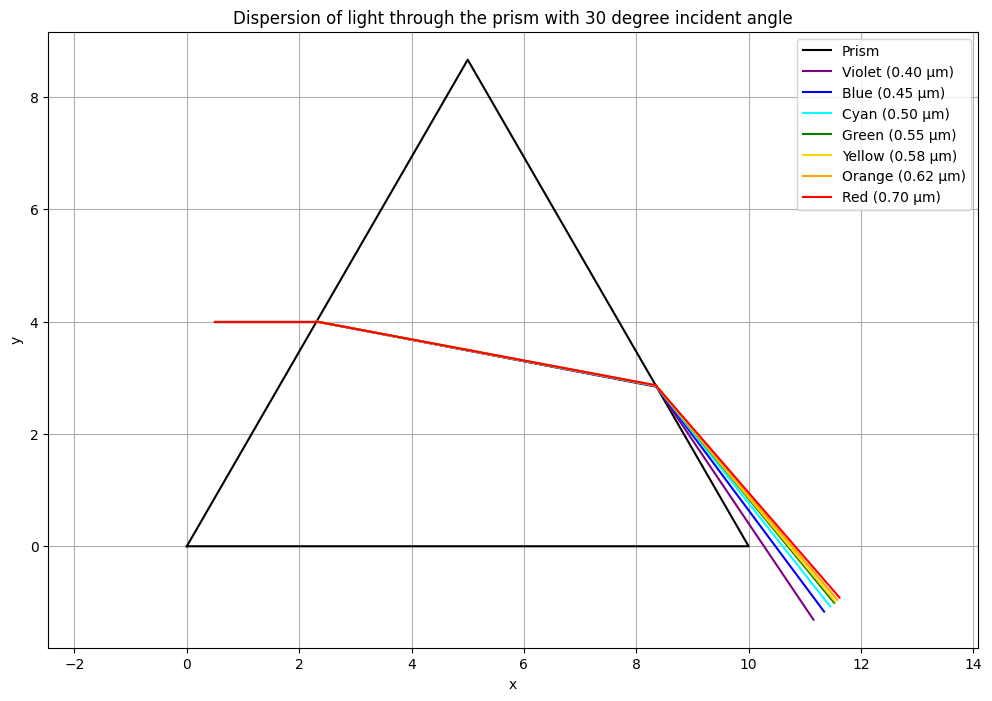

,wavelength (µm),Refractive index,Incident angle (Degree),Ray entry horizontal angle (Degree),Entry_point,Refracted angle inside (Degree),Inside Direction of ray,Inside horizontal angle (Degree),Exit_point,Exit_side,Incident angle inside (Degree),Exit refracted angle (Degree),Exit direction,Exit horizontal angle (Degree)
Color,,,,,,,,,,,,,,
Violet,0.40,1.525,45,15.0,"(2.641, 4.574)",27.6261,"(0.999, -0.041)",-2.3739,"(7.475, 4.373)","([5.0, 8.660254037844386], [10, 0])",32.3739,54.7359,"(0.908, -0.418)",-24.7359
Blue,0.45,1.520,45,15.0,"(2.641, 4.574)",27.7232,"(0.999, -0.04)",-2.2768,"(7.47, 4.382)","([5.0, 8.660254037844386], [10, 0])",32.2768,54.2624,"(0.912, -0.411)",-24.2624
Cyan,0.50,1.516,45,15.0,"(2.641, 4.574)",27.8009,"(0.999, -0.038)",-2.1991,"(7.466, 4.388)","([5.0, 8.660254037844386], [10, 0])",32.1991,53.8815,"(0.914, -0.405)",-23.8815
Green,0.55,1.513,45,15.0,"(2.641, 4.574)",27.8657,"(0.999, -0.037)",-2.1343,"(7.463, 4.394)","([5.0, 8.660254037844386], [10, 0])",32.1343,53.5909,"(0.916, -0.4)",-23.5909
Yellow,0.58,1.512,45,15.0,"(2.641, 4.574)",27.8851,"(0.999, -0.037)",-2.1149,"(7.462, 4.395)","([5.0, 8.660254037844386], [10, 0])",32.1149,53.4945,"(0.917, -0.399)",-23.4945
Orange,0.62,1.510,45,15.0,"(2.641, 4.574)",27.9240,"(0.999, -0.036)",-2.0760,"(7.46, 4.399)","([5.0, 8.660254037844386], [10, 0])",32.0760,53.3119,"(0.918, -0.396)",-23.3119
Red,0.70,1.508,45,15.0,"(2.641, 4.574)",27.9629,"(0.999, -0.036)",-2.0371,"(7.458, 4.402)","([5.0, 8.660254037844386], [10, 0])",32.0371,53.1206,"(0.92, -0.393)",-23.1206


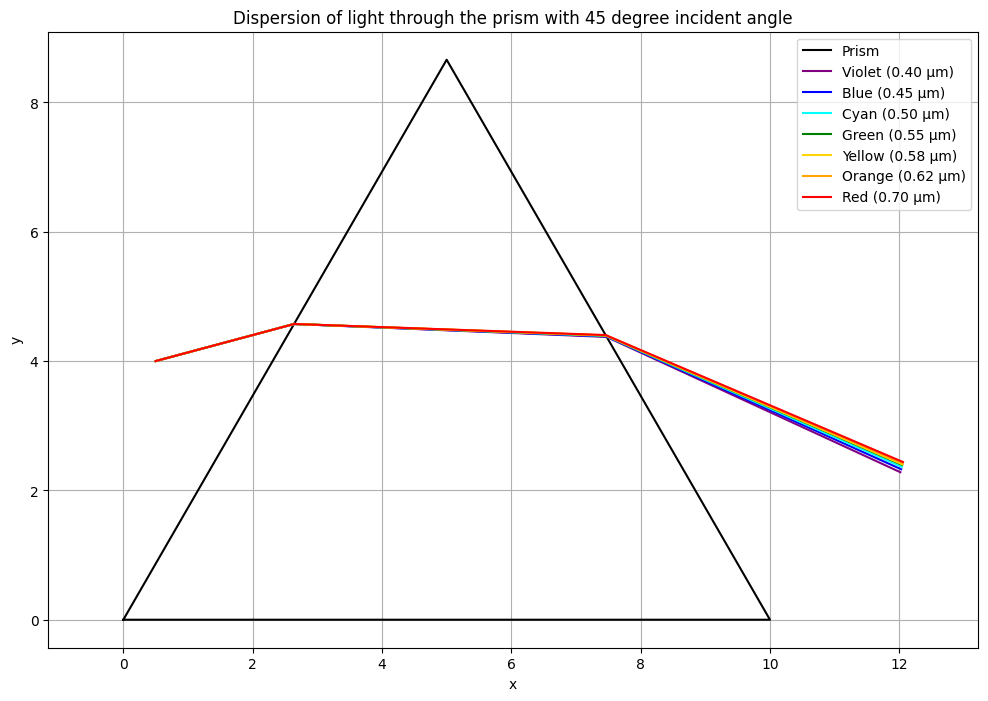

,wavelength (µm),Refractive index,Incident angle (Degree),Ray entry horizontal angle (Degree),Entry_point,Refracted angle inside (Degree),Inside Direction of ray,Inside horizontal angle (Degree),Exit_point,Exit_side,Incident angle inside (Degree),Exit refracted angle (Degree),Exit direction,Exit horizontal angle (Degree)
Color,,,,,,,,,,,,,,
Violet,0.40,1.525,60,30.0,"(3.214, 5.567)",34.6039,"(0.997, 0.08)",4.6039,"(6.627, 5.842)","([5.0, 8.660254037844386], [10, 0])",25.3961,40.8439,"(0.982, -0.188)",-10.8439
Blue,0.45,1.520,60,30.0,"(3.214, 5.567)",34.7363,"(0.997, 0.083)",4.7363,"(6.623, 5.849)","([5.0, 8.660254037844386], [10, 0])",25.2637,40.4437,"(0.983, -0.181)",-10.4437
Cyan,0.50,1.516,60,30.0,"(3.214, 5.567)",34.8409,"(0.996, 0.084)",4.8409,"(6.619, 5.855)","([5.0, 8.660254037844386], [10, 0])",25.1591,40.1282,"(0.984, -0.176)",-10.1282
Green,0.55,1.513,60,30.0,"(3.214, 5.567)",34.9178,"(0.996, 0.086)",4.9178,"(6.617, 5.86)","([5.0, 8.660254037844386], [10, 0])",25.0822,39.8963,"(0.985, -0.172)",-9.8963
Yellow,0.58,1.512,60,30.0,"(3.214, 5.567)",34.9457,"(0.996, 0.086)",4.9457,"(6.616, 5.861)","([5.0, 8.660254037844386], [10, 0])",25.0543,39.8142,"(0.985, -0.17)",-9.8142
Orange,0.62,1.510,60,30.0,"(3.214, 5.567)",34.9947,"(0.996, 0.087)",4.9947,"(6.614, 5.864)","([5.0, 8.660254037844386], [10, 0])",25.0053,39.6652,"(0.986, -0.168)",-9.6652
Red,0.70,1.508,60,30.0,"(3.214, 5.567)",35.0506,"(0.996, 0.088)",5.0506,"(6.612, 5.867)","([5.0, 8.660254037844386], [10, 0])",24.9494,39.5016,"(0.986, -0.165)",-9.5016


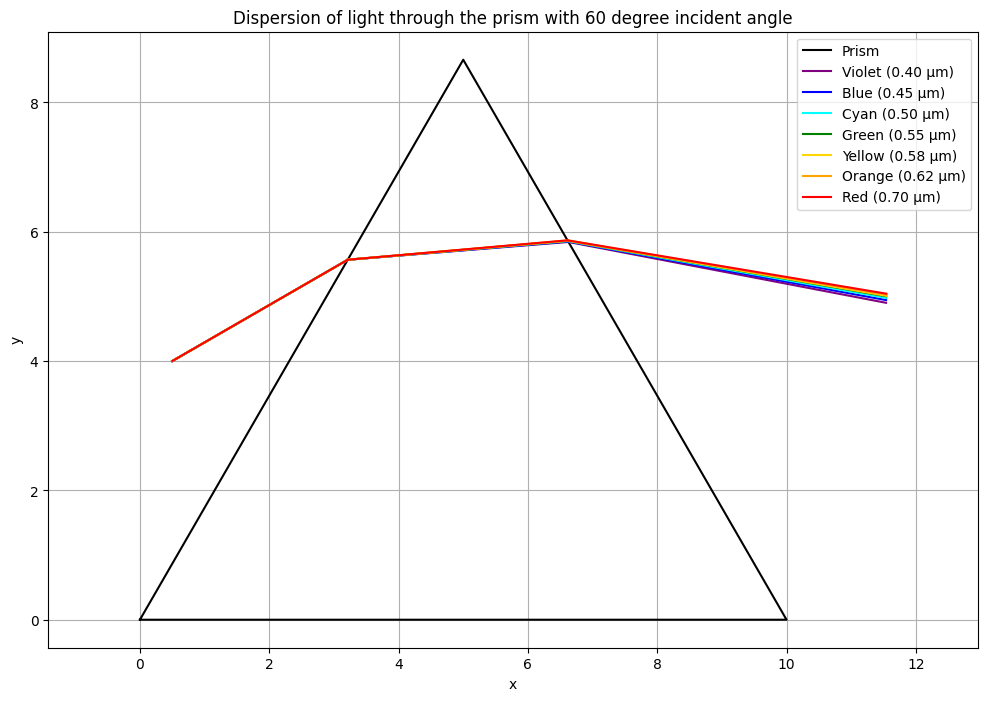

,wavelength (µm),Refractive index,Incident angle (Degree),Ray entry horizontal angle (Degree),Entry_point,Refracted angle inside (Degree),Inside Direction of ray,Inside horizontal angle (Degree),Exit_point,Exit_side,Incident angle inside (Degree),Exit refracted angle (Degree),Exit direction,Exit horizontal angle (Degree)
Color,,,,,,,,,,,,,,
Violet,0.40,1.525,-30,-60.0,"(1.405, 2.433)",-19.1414,"(0.654, -0.756)",-49.1414,"(3.509, 0.0)","([10, 0], [0, 0])",40.8586,86.0296,"(0.998, -0.069)",-3.9704
Blue,0.45,1.520,-30,-60.0,"(1.405, 2.433)",-19.2020,"(0.653, -0.757)",-49.2020,"(3.505, -0.0)","([10, 0], [0, 0])",40.7980,83.3144,"(0.993, -0.116)",-6.6856
Cyan,0.50,1.516,-30,-60.0,"(1.405, 2.433)",-19.2566,"(0.653, -0.758)",-49.2566,"(3.501, 0.0)","([10, 0], [0, 0])",40.7434,81.6898,"(0.99, -0.145)",-8.3102
Green,0.55,1.513,-30,-60.0,"(1.405, 2.433)",-19.2991,"(0.652, -0.758)",-49.2991,"(3.497, 0.0)","([10, 0], [0, 0])",40.7009,80.6098,"(0.987, -0.163)",-9.3902
Yellow,0.58,1.512,-30,-60.0,"(1.405, 2.433)",-19.3113,"(0.652, -0.758)",-49.3113,"(3.497, 0.0)","([10, 0], [0, 0])",40.6887,80.2988,"(0.986, -0.169)",-9.7012
Orange,0.62,1.510,-30,-60.0,"(1.405, 2.433)",-19.3356,"(0.652, -0.759)",-49.3356,"(3.495, 0.0)","([10, 0], [0, 0])",40.6644,79.7369,"(0.984, -0.178)",-10.2631
Red,0.70,1.508,-30,-60.0,"(1.405, 2.433)",-19.3659,"(0.651, -0.759)",-49.3659,"(3.493, 0.0)","([10, 0], [0, 0])",40.6341,79.1125,"(0.982, -0.189)",-10.8875


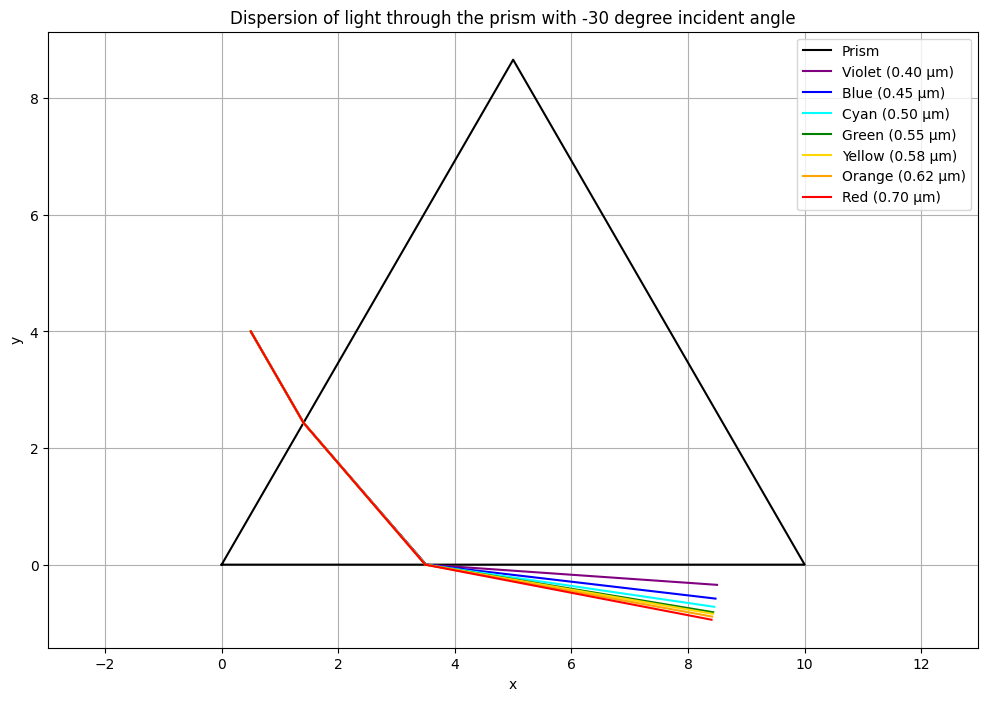

,wavelength (µm),Refractive index,Incident angle (Degree),Ray entry horizontal angle (Degree),Entry_point,Refracted angle inside (Degree),Inside Direction of ray,Inside horizontal angle (Degree),Exit_point,Exit_side,Incident angle inside (Degree),Exit refracted angle (Degree),Exit direction,Exit horizontal angle (Degree)
Color,,,,,,,,,,,,,,
Violet,0.40,1.525,-45,-75.0,"(1.074, 1.859)",-27.6261,"(0.535, -0.845)",-57.6261,"(2.252, -0.0)","([10, 0], [0, 0])",32.3739,54.7359,"(0.816, -0.577)",-35.2641
Blue,0.45,1.520,-45,-75.0,"(1.074, 1.859)",-27.7232,"(0.534, -0.845)",-57.7232,"(2.248, 0.0)","([10, 0], [0, 0])",32.2768,54.2624,"(0.812, -0.584)",-35.7376
Cyan,0.50,1.516,-45,-75.0,"(1.074, 1.859)",-27.8009,"(0.533, -0.846)",-57.8009,"(2.244, 0.0)","([10, 0], [0, 0])",32.1991,53.8815,"(0.808, -0.589)",-36.1185
Green,0.55,1.513,-45,-75.0,"(1.074, 1.859)",-27.8657,"(0.532, -0.847)",-57.8657,"(2.242, -0.0)","([10, 0], [0, 0])",32.1343,53.5909,"(0.805, -0.594)",-36.4091
Yellow,0.58,1.512,-45,-75.0,"(1.074, 1.859)",-27.8851,"(0.532, -0.847)",-57.8851,"(2.241, 0.0)","([10, 0], [0, 0])",32.1149,53.4945,"(0.804, -0.595)",-36.5055
Orange,0.62,1.510,-45,-75.0,"(1.074, 1.859)",-27.9240,"(0.531, -0.847)",-57.9240,"(2.239, -0.0)","([10, 0], [0, 0])",32.0760,53.3119,"(0.802, -0.597)",-36.6881
Red,0.70,1.508,-45,-75.0,"(1.074, 1.859)",-27.9629,"(0.53, -0.848)",-57.9629,"(2.237, 0.0)","([10, 0], [0, 0])",32.0371,53.1206,"(0.8, -0.6)",-36.8794


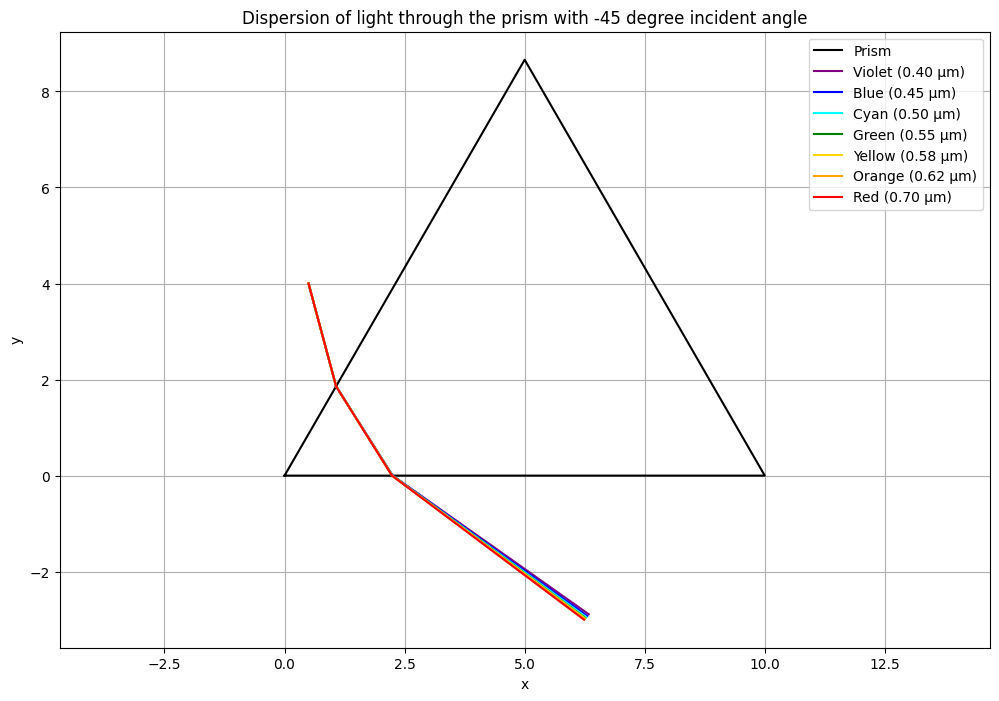

,wavelength (µm),Refractive index,Incident angle (Degree),Ray entry horizontal angle (Degree),Entry_point,Refracted angle inside (Degree),Inside Direction of ray,Inside horizontal angle (Degree),Exit_point,Exit_side,Incident angle inside (Degree),Exit refracted angle (Degree),Exit direction,Exit horizontal angle (Degree)
Color,,,,,,,,,,,,,,
Violet,0.40,1.525,-60,-90.0,"(0.5, 0.866)",-34.6039,"(0.429, -0.903)",-64.6039,"(0.911, -0.0)","([10, 0], [0, 0])",25.3961,40.8439,"(0.654, -0.756)",-49.1561
Blue,0.45,1.520,-60,-90.0,"(0.5, 0.866)",-34.7363,"(0.427, -0.904)",-64.7363,"(0.909, -0.0)","([10, 0], [0, 0])",25.2637,40.4437,"(0.649, -0.761)",-49.5563
Cyan,0.50,1.516,-60,-90.0,"(0.5, 0.866)",-34.8409,"(0.425, -0.905)",-64.8409,"(0.907, 0.0)","([10, 0], [0, 0])",25.1591,40.1282,"(0.645, -0.765)",-49.8718
Green,0.55,1.513,-60,-90.0,"(0.5, 0.866)",-34.9178,"(0.424, -0.906)",-64.9178,"(0.905, 0.0)","([10, 0], [0, 0])",25.0822,39.8963,"(0.641, -0.767)",-50.1037
Yellow,0.58,1.512,-60,-90.0,"(0.5, 0.866)",-34.9457,"(0.423, -0.906)",-64.9457,"(0.905, 0.0)","([10, 0], [0, 0])",25.0543,39.8142,"(0.64, -0.768)",-50.1858
Orange,0.62,1.510,-60,-90.0,"(0.5, 0.866)",-34.9947,"(0.423, -0.906)",-64.9947,"(0.904, 0.0)","([10, 0], [0, 0])",25.0053,39.6652,"(0.638, -0.77)",-50.3348
Red,0.70,1.508,-60,-90.0,"(0.5, 0.866)",-35.0506,"(0.422, -0.907)",-65.0506,"(0.903, -0.0)","([10, 0], [0, 0])",24.9494,39.5016,"(0.636, -0.772)",-50.4984


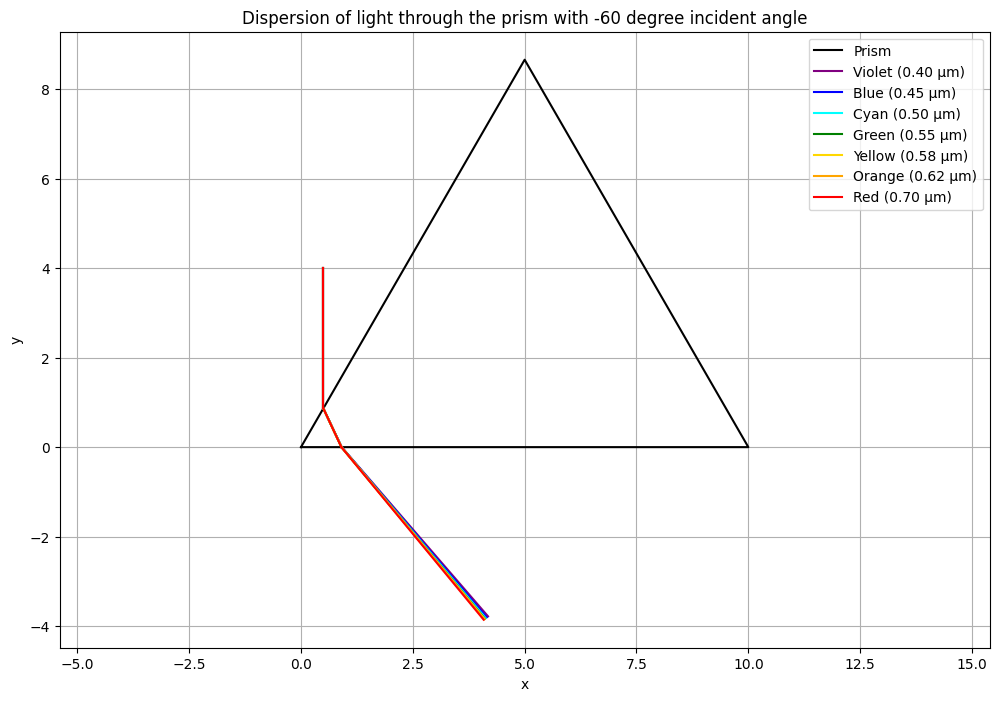

In [83]:
n_air = 1
ray_origin = np.array([0.5, 4])  # Starting point of the ray
incident_angles = [30, 45, 60, -30, -45, -60] # Incident angle in degrees

color_map = {
    "Violet": "purple",
    "Blue": "blue",
    "Cyan": "cyan",
    "Green": "green",
    "Yellow": "gold",
    "Orange": "orange",
    "Red": "red"
}

for angle in incident_angles:
    results = {}

    for color, wavelength in wavelengths.items():
        # incoming ray
        incoming_origin, incoming_dir, incoming_angle = make_incident_ray(
            ray_origin, angle, A, C, prism_center
        )

        # entry intersection
        entry_result = ray_prism_intersection(incoming_origin, incoming_dir, A, C)

        if entry_result is None:
            print(f"{color}: ray missed the prism for incident angle {angle}")
            results[color] = None
            continue

        entry_point, t_enter, u_enter = entry_result

        # refraction into prism
        refracted_enter_angle, n_prism = snell_law_enter(angle, wavelength, n_air)

        # inside ray
        inside_origin, inside_dir, inside_angle = make_inside_ray(
            entry_point, refracted_enter_angle, A, C, prism_center
        )
        inside_origin = inside_origin + 1e-6 * inside_dir

        # exit intersection
        exit_result = ray_prism_exit_intersection(
            inside_origin, inside_dir, exclude_side=(A, C)
        )

        if exit_result is None:
            print(f"{color}: no exit found for incident angle {angle}")
            results[color] = {
                "wavelength (µm)": wavelength,
                "Refractive index": n_prism,
                "Incident angle (Degree)": angle,
                "Ray entry horizontal angle (Degree)": incoming_angle,
                "Entry_point": entry_point,
                "Refracted angle inside (Degree)": refracted_enter_angle,
                "Inside Direction of ray": inside_dir,
                "Inside horizontal angle (Degree)": inside_angle,
                "Exit_point": None,
                "Exit_side": None,
                "Incident angle inside (Degree)": None,
                "Exit refracted angle (Degree)": None,
                "Exit direction": None,
                "Exit horizontal angle (Degree)": None
            }
            continue

        exit_point, t_exit, u_exit, exit_side = exit_result

        # exit refraction
        refracted_exit_angle, incident_angle_inside = snell_law_exit(
            inside_angle, exit_side[0], exit_side[1], wavelength, n_air
        )

        # total internal reflection case
        if refracted_exit_angle is None:
            print(f"{color}: total internal reflection for incident angle {angle}")
            results[color] = {
                "wavelength (µm)": wavelength,
                "Refractive index": n_prism,
                "Incident angle (Degree)": angle,
                "Ray entry horizontal angle (Degree)": incoming_angle,
                "Entry_point": entry_point,
                "Refracted angle inside (Degree)": refracted_enter_angle,
                "Inside Direction of ray": inside_dir,
                "Inside horizontal angle (Degree)": inside_angle,
                "Exit_point": exit_point,
                "Exit_side": exit_side,
                "Incident angle inside (Degree)": incident_angle_inside,
                "Exit refracted angle (Degree)": None,
                "Exit direction": None,
                "Exit horizontal angle (Degree)": None
            }
            continue

        # outgoing ray
        exit_origin, exit_dir, exit_angle = make_exit_ray(
            exit_point, refracted_exit_angle, exit_side, exit_side[0], exit_side[1]
        )

        results[color] = {
            "wavelength (µm)": wavelength,
            "Refractive index": n_prism,
            "Incident angle (Degree)": angle,
            "Ray entry horizontal angle (Degree)": incoming_angle,
            "Entry_point": entry_point,
            "Refracted angle inside (Degree)": refracted_enter_angle,
            "Inside Direction of ray": inside_dir,
            "Inside horizontal angle (Degree)": inside_angle,
            "Exit_point": exit_point,
            "Exit_side": exit_side,
            "Incident angle inside (Degree)": incident_angle_inside,
            "Exit refracted angle (Degree)": refracted_exit_angle,
            "Exit direction": exit_dir,
            "Exit horizontal angle (Degree)": exit_angle
        }

    # display table
    clean_results = {}
    for color, result in results.items():
        if result is None:
            continue

        clean = result.copy()

        if clean["Entry_point"] is not None:
            clean["Entry_point"] = tuple(np.round(clean["Entry_point"], 3))
        if clean["Inside Direction of ray"] is not None:
            clean["Inside Direction of ray"] = tuple(np.round(clean["Inside Direction of ray"], 3))
        if clean["Exit_point"] is not None:
            clean["Exit_point"] = tuple(np.round(clean["Exit_point"], 3))
        if clean["Exit direction"] is not None:
            clean["Exit direction"] = tuple(np.round(clean["Exit direction"], 3))

        clean_results[color] = clean

    results_df = pd.DataFrame.from_dict(clean_results, orient="index")
    results_df.index.name = "Color"
    display(results_df)

    # plot
    plt.figure(figsize=(12, 8))

    triangle_x = [A[0], C[0], B[0], A[0]]
    triangle_y = [A[1], C[1], B[1], A[1]]
    plt.plot(triangle_x, triangle_y, 'k-', label='Prism')

    for color, result in results.items():
        if result is None:
            continue

        entry_point = result["Entry_point"]
        inside_dir = result["Inside Direction of ray"]
        exit_point = result["Exit_point"]
        exit_dir = result["Exit direction"]

        # incoming segment
        plt.plot([ray_origin[0], entry_point[0]],
                 [ray_origin[1], entry_point[1]],
                 color=color_map[color])

        # if there is no exit ray, just plot entry and inside path if possible
        if exit_point is None:
            continue

        # inside segment
        plt.plot([entry_point[0], exit_point[0]],
                 [entry_point[1], exit_point[1]],
                 color=color_map[color])

        # outgoing segment only if it exists
        if exit_dir is not None:
            end_out = exit_point + 5 * exit_dir
            plt.plot([exit_point[0], end_out[0]],
                     [exit_point[1], end_out[1]],
                     color=color_map[color],
                     label=f"{color} ({wavelengths[color]:.2f} µm)")
        else:
            # still include label if no exiting ray
            plt.scatter(exit_point[0], exit_point[1],
                        color=color_map[color],
                        label=f"{color} ({wavelengths[color]:.2f} µm, TIR)")

    plt.grid()
    plt.legend()
    plt.axis('equal')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Dispersion of light through the prism with {angle} degree incident angle")
    plt.show()

# Analysis based on the wavelength dependence of refractive index:
As we can see in the tables above for various dispersion scenarios, the refractive index changes with the wavelength of light, with the shortest wavelength having the highest n (violet) and the longest wavelength having the lowest n (red). As the n increases, the refraction angle for that wavelength inside the prism is going to be lower. That's why we observe violet have the lowest refraction angle inside the prism. As we exit the prism, our rays should get more away from the normal to the exit face since we are entering a medium with lower n (air). This would cause the shortest wavelength to have the highest refraction angle and thus, bend the most. The calculations shown in the tables confirm this.

# Analysis based on the figures:
As you could see in the figures above, different wavelengths of light are dispersed as we exit the prism on the other side. Based on the snell's law, the lowest the wavelength, the higher the refraction angle and the bend. This is observed in all scenarios, where the violet light is bent the most and the red light is bent the least.

# Model Validation
For validation, I'm going to test the incident angle of zero. We know that at an incident angle of zero, the ray should enter the prism without any refraction and it should follow the same direction through the prism as it entered. In addition, since our prism is a equilateral with internal angles of 60 degrees, the ray entering one side of the prism at zero degree incident angle will hit the other face of the prism at an incident angle of 60 degrees. By using the snell's law for the exiting ray, the sine of the exiting refraction angle will be >1, which is impossible. In this case, an internal dispersion happens and we should not see any rays exiting the prism. Asa result, the ray should stop where it hits the exiting face, since I did not define internal dispersion in my model.

Total internal reflection occurs, no refraction outside the prism
Violet: total internal reflection for incident angle 0
Total internal reflection occurs, no refraction outside the prism
Blue: total internal reflection for incident angle 0
Total internal reflection occurs, no refraction outside the prism
Cyan: total internal reflection for incident angle 0
Total internal reflection occurs, no refraction outside the prism
Green: total internal reflection for incident angle 0
Total internal reflection occurs, no refraction outside the prism
Yellow: total internal reflection for incident angle 0
Total internal reflection occurs, no refraction outside the prism
Orange: total internal reflection for incident angle 0
Total internal reflection occurs, no refraction outside the prism
Red: total internal reflection for incident angle 0


,wavelength (µm),Refractive index,Incident angle (Degree),Ray entry horizontal angle (Degree),Entry_point,Refracted angle inside (Degree),Inside Direction of ray,Inside horizontal angle (Degree),Exit_point,Exit_side,Incident angle inside (Degree),Exit refracted angle (Degree),Exit direction,Exit horizontal angle (Degree)
Color,,,,,,,,,,,,,,
Violet,0.40,1.525,0,-30.0,"(2.723, 4.717)",0.0,"(0.866, -0.5)",-30.0,"(9.554, 0.773)","([5.0, 8.660254037844386], [10, 0])",60.0,None,None,None
Blue,0.45,1.520,0,-30.0,"(2.723, 4.717)",0.0,"(0.866, -0.5)",-30.0,"(9.554, 0.773)","([5.0, 8.660254037844386], [10, 0])",60.0,None,None,None
Cyan,0.50,1.516,0,-30.0,"(2.723, 4.717)",0.0,"(0.866, -0.5)",-30.0,"(9.554, 0.773)","([5.0, 8.660254037844386], [10, 0])",60.0,None,None,None
Green,0.55,1.513,0,-30.0,"(2.723, 4.717)",0.0,"(0.866, -0.5)",-30.0,"(9.554, 0.773)","([5.0, 8.660254037844386], [10, 0])",60.0,None,None,None
Yellow,0.58,1.512,0,-30.0,"(2.723, 4.717)",0.0,"(0.866, -0.5)",-30.0,"(9.554, 0.773)","([5.0, 8.660254037844386], [10, 0])",60.0,None,None,None
Orange,0.62,1.510,0,-30.0,"(2.723, 4.717)",0.0,"(0.866, -0.5)",-30.0,"(9.554, 0.773)","([5.0, 8.660254037844386], [10, 0])",60.0,None,None,None
Red,0.70,1.508,0,-30.0,"(2.723, 4.717)",0.0,"(0.866, -0.5)",-30.0,"(9.554, 0.773)","([5.0, 8.660254037844386], [10, 0])",60.0,None,None,None


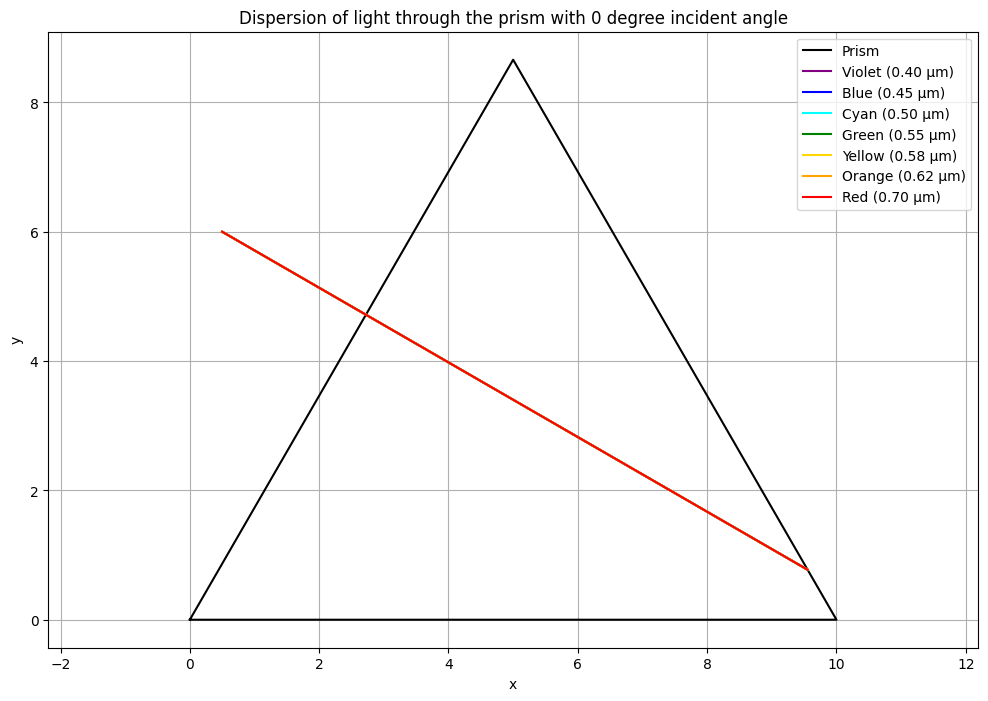

In [84]:
n_air = 1
ray_origin = np.array([0.5, 6])  # Starting point of the ray
incident_angles = [0] # Incident angle in degrees

color_map = {
    "Violet": "purple",
    "Blue": "blue",
    "Cyan": "cyan",
    "Green": "green",
    "Yellow": "gold",
    "Orange": "orange",
    "Red": "red"
}

for angle in incident_angles:
    results = {}

    for color, wavelength in wavelengths.items():
        # incoming ray
        incoming_origin, incoming_dir, incoming_angle = make_incident_ray(
            ray_origin, angle, A, C, prism_center
        )

        # entry intersection
        entry_result = ray_prism_intersection(incoming_origin, incoming_dir, A, C)

        if entry_result is None:
            print(f"{color}: ray missed the prism for incident angle {angle}")
            results[color] = None
            continue

        entry_point, t_enter, u_enter = entry_result

        # refraction into prism
        refracted_enter_angle, n_prism = snell_law_enter(angle, wavelength, n_air)

        # inside ray
        inside_origin, inside_dir, inside_angle = make_inside_ray(
            entry_point, refracted_enter_angle, A, C, prism_center
        )
        inside_origin = inside_origin + 1e-6 * inside_dir

        # exit intersection
        exit_result = ray_prism_exit_intersection(
            inside_origin, inside_dir, exclude_side=(A, C)
        )

        if exit_result is None:
            print(f"{color}: no exit found for incident angle {angle}")
            results[color] = {
                "wavelength (µm)": wavelength,
                "Refractive index": n_prism,
                "Incident angle (Degree)": angle,
                "Ray entry horizontal angle (Degree)": incoming_angle,
                "Entry_point": entry_point,
                "Refracted angle inside (Degree)": refracted_enter_angle,
                "Inside Direction of ray": inside_dir,
                "Inside horizontal angle (Degree)": inside_angle,
                "Exit_point": None,
                "Exit_side": None,
                "Incident angle inside (Degree)": None,
                "Exit refracted angle (Degree)": None,
                "Exit direction": None,
                "Exit horizontal angle (Degree)": None
            }
            continue

        exit_point, t_exit, u_exit, exit_side = exit_result

        # exit refraction
        refracted_exit_angle, incident_angle_inside = snell_law_exit(
            inside_angle, exit_side[0], exit_side[1], wavelength, n_air
        )

        # total internal reflection case
        if refracted_exit_angle is None:
            print(f"{color}: total internal reflection for incident angle {angle}")
            results[color] = {
                "wavelength (µm)": wavelength,
                "Refractive index": n_prism,
                "Incident angle (Degree)": angle,
                "Ray entry horizontal angle (Degree)": incoming_angle,
                "Entry_point": entry_point,
                "Refracted angle inside (Degree)": refracted_enter_angle,
                "Inside Direction of ray": inside_dir,
                "Inside horizontal angle (Degree)": inside_angle,
                "Exit_point": exit_point,
                "Exit_side": exit_side,
                "Incident angle inside (Degree)": incident_angle_inside,
                "Exit refracted angle (Degree)": None,
                "Exit direction": None,
                "Exit horizontal angle (Degree)": None
            }
            continue

        # outgoing ray
        exit_origin, exit_dir, exit_angle = make_exit_ray(
            exit_point, refracted_exit_angle, exit_side, exit_side[0], exit_side[1]
        )

        results[color] = {
            "wavelength (µm)": wavelength,
            "Refractive index": n_prism,
            "Incident angle (Degree)": angle,
            "Ray entry horizontal angle (Degree)": incoming_angle,
            "Entry_point": entry_point,
            "Refracted angle inside (Degree)": refracted_enter_angle,
            "Inside Direction of ray": inside_dir,
            "Inside horizontal angle (Degree)": inside_angle,
            "Exit_point": exit_point,
            "Exit_side": exit_side,
            "Incident angle inside (Degree)": incident_angle_inside,
            "Exit refracted angle (Degree)": refracted_exit_angle,
            "Exit direction": exit_dir,
            "Exit horizontal angle (Degree)": exit_angle
        }

    # display table
    clean_results = {}
    for color, result in results.items():
        if result is None:
            continue

        clean = result.copy()

        if clean["Entry_point"] is not None:
            clean["Entry_point"] = tuple(np.round(clean["Entry_point"], 3))
        if clean["Inside Direction of ray"] is not None:
            clean["Inside Direction of ray"] = tuple(np.round(clean["Inside Direction of ray"], 3))
        if clean["Exit_point"] is not None:
            clean["Exit_point"] = tuple(np.round(clean["Exit_point"], 3))
        if clean["Exit direction"] is not None:
            clean["Exit direction"] = tuple(np.round(clean["Exit direction"], 3))

        clean_results[color] = clean

    results_df = pd.DataFrame.from_dict(clean_results, orient="index")
    results_df.index.name = "Color"
    display(results_df)

    # plot
    plt.figure(figsize=(12, 8))

    triangle_x = [A[0], C[0], B[0], A[0]]
    triangle_y = [A[1], C[1], B[1], A[1]]
    plt.plot(triangle_x, triangle_y, 'k-', label='Prism')

    for color, result in results.items():
        if result is None:
            continue

        entry_point = result["Entry_point"]
        inside_dir = result["Inside Direction of ray"]
        exit_point = result["Exit_point"]
        exit_dir = result["Exit direction"]

        # incoming segment
        plt.plot([ray_origin[0], entry_point[0]],
                 [ray_origin[1], entry_point[1]],
                 color=color_map[color])

        # if there is no exit ray, just plot entry and inside path if possible
        if exit_point is None:
            continue

        # inside segment
        plt.plot([entry_point[0], exit_point[0]],
                 [entry_point[1], exit_point[1]],
                 color=color_map[color],
                 label=f"{color} ({wavelengths[color]:.2f} µm)")

        # outgoing segment only if it exists
        if exit_dir is not None:
            end_out = exit_point + 5 * exit_dir
            plt.plot([exit_point[0], end_out[0]],
                     [exit_point[1], end_out[1]],
                     color=color_map[color],
                     label=f"{color} ({wavelengths[color]:.2f} µm)")


    plt.grid()
    plt.legend()
    plt.axis('equal')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Dispersion of light through the prism with {angle} degree incident angle")
    plt.show()

As predicted, the ray does not refract as it enters the prism and it stops as it hits the exiting face.

# AI Usage
I used ChatGPT to walk me through the coding process. I first define the physics logic and manually calculate the dispersion for 3 different incident angles. Then, I started writing the code and functions step by step to implement the physics of the model. In this process, I introduced my physics logic to ChatGPT to help me with implementation of some vector operations, angle calculations, and loop and logics that I wasn't sure how to code. I also sue ChatGPT to address the errors I got while running the code. 